## Progetto Deep Learning - Project 3 - Detection and Localisation of Bone Fractures on X-rays 

*Salvatore Emmanuel La Porta - 1000081957*



## 1. Setup e Import

Innanzitutto importiamo tutte le librerie e definiamo tutte le costanti e path che serviranno per il progetto.

In [7]:
import os
import sys
import shutil
import subprocess
from pathlib import Path
from collections import Counter
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import yaml
import cv2
import pandas as pd

from ultralytics import YOLO

BASE_DIR         = Path("Progetto_DL_1000081957_data")
DATASETS_DIR     = BASE_DIR / "datasets"
ORIGINALS_DIR    = DATASETS_DIR / "originals"
PREPROCESSED_DIR = DATASETS_DIR / "preprocessed"
RUNS_DIR         = BASE_DIR / "runs"
FRACATLAS_DIR   = ORIGINALS_DIR / "fracatlas"
PKDARABI_DIR    = ORIGINALS_DIR / "pkdarabi"

PKDARABI_ORIG = BASE_DIR / "datasets" / "originals" / "pkdarabi"
PKDARABI_PREP = BASE_DIR / "datasets" / "preprocessed" / "pkdarabi"
PKDARABI_CLAHE = BASE_DIR / "datasets" / "preprocessed" / "pkdarabi_clahe"
PKDARABI_AUG = BASE_DIR / "datasets" / "preprocessed" / "pkdarabi_aug"




for d in [BASE_DIR, DATASETS_DIR, ORIGINALS_DIR, PREPROCESSED_DIR,
          RUNS_DIR, FRACATLAS_DIR, PKDARABI_DIR]:
    d.mkdir(parents=True, exist_ok=True)

KAGGLE_PKDARABI  = "pkdarabi/bone-fracture-detection-computer-vision-project"
KAGGLE_FRACATLAS = "mahmudulhasantasin/fracatlas-original-dataset"

print(f"BASE_DIR        : {BASE_DIR.resolve()}")
print(f"ORIGINALS_DIR   : {ORIGINALS_DIR.resolve()}")
print(f"PREPROCESSED_DIR: {PREPROCESSED_DIR.resolve()}")
print(f"RUNS_DIR        : {RUNS_DIR.resolve()}")

BASE_DIR        : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data
ORIGINALS_DIR   : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\originals
PREPROCESSED_DIR: C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed
RUNS_DIR        : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs


## 2. Download e Analisi Esplorativa dei Dataset

Dalla documentazione del progetto, sono presenti due dataset da utilizzare:

- **FracAtlas** (mahmudulhasantasin/fracatlas-original-dataset):
  possiede annotazioni in vari formati, tra cui YOLO. Le immagini sono divise in Fractured e
  Non_fractured senza split train/valid/test predefiniti bilanciati.

- **Bone Fracture Detection** (pkdarabi/bone-fracture-detection-computer-vision-project):
  versione pre-processata in formato YOLO nativo, con split train/valid/test
  gia' definiti e 7 classi anatomiche.

Scarichiamo entrambi, ne analizziamo la struttura e usiamo i dati per
motivare la scelta del dataset di lavoro.

In [2]:
# --- pkdarabi: ha data.yaml, download diretto ---
def download_pkdarabi(kaggle_slug, dest_dir):
    cache_path = Path(kagglehub.dataset_download(kaggle_slug))
    print(f"Cache: {cache_path}")

    yaml_candidates = list(cache_path.rglob("data.yaml"))
    assert yaml_candidates, f"data.yaml non trovato in {cache_path}"

    src_root = yaml_candidates[0].parent
    print(f"Sorgente: {src_root}")

    if not (dest_dir / "train" / "images").exists():
        for item in src_root.iterdir():
            dst = dest_dir / item.name
            if dst.exists():
                continue
            if item.is_dir():
                shutil.copytree(item, dst)
            else:
                shutil.copy2(item, dst)
        print("Copia completata.")
    else:
        print("(skip) dataset gia' presente.")

    return dest_dir / "data.yaml"

print("=== Download pkdarabi ===")
pkdarabi_yaml_path = download_pkdarabi(KAGGLE_PKDARABI, PKDARABI_DIR)

=== Download pkdarabi ===
Cache: C:\Users\emm97\.cache\kagglehub\datasets\pkdarabi\bone-fracture-detection-computer-vision-project\versions\2
Sorgente: C:\Users\emm97\.cache\kagglehub\datasets\pkdarabi\bone-fracture-detection-computer-vision-project\versions\2\bone fracture detection.v4-v4.yolov8
(skip) dataset gia' presente.


In [3]:
# --- FracAtlas: non ha data.yaml, struttura custom ---
def download_fracatlas(kaggle_slug, dest_dir):
    cache_path = Path(kagglehub.dataset_download(kaggle_slug))
    print(f"Cache: {cache_path}")

    src_root = cache_path / "FracAtlas"
    assert src_root.exists(), f"Cartella FracAtlas non trovata in {cache_path}"
    print(f"Sorgente: {src_root}")

    if not (dest_dir / "Annotations").exists():
        for item in src_root.iterdir():
            dst = dest_dir / item.name
            if dst.exists():
                continue
            if item.is_dir():
                shutil.copytree(item, dst)
            else:
                shutil.copy2(item, dst)
        print("Copia completata.")
    else:
        print("(skip) dataset gia' presente.")

    return dest_dir

print("=== Download FracAtlas ===")
fracatlas_root = download_fracatlas(KAGGLE_FRACATLAS, FRACATLAS_DIR)

=== Download FracAtlas ===
Cache: C:\Users\emm97\.cache\kagglehub\datasets\mahmudulhasantasin\fracatlas-original-dataset\versions\1
Sorgente: C:\Users\emm97\.cache\kagglehub\datasets\mahmudulhasantasin\fracatlas-original-dataset\versions\1\FracAtlas
(skip) dataset gia' presente.


### 2.1 Analisi FracAtlas

FracAtlas non e' in formato YOLO nativo: è vero che ci sono le annotazioni YOLO (txt), ma le immagini non sono
organizzate in split train/valid/test. La struttura e':

In [6]:
fracatlas_root = FRACATLAS_DIR

print("FracAtlas/")
for level1 in sorted(fracatlas_root.iterdir()):
    is_last1 = level1 == sorted(fracatlas_root.iterdir())[-1]
    prefix1 = "└── " if is_last1 else "├── "
    suffix = "/" if level1.is_dir() else ""
    print(f"{prefix1}{level1.name}{suffix}")
    if level1.is_dir():
        children = sorted(level1.iterdir())
        for i, level2 in enumerate(children):
            is_last2 = i == len(children) - 1
            prefix2 = ("    " if is_last1 else "│   ") + ("└── " if is_last2 else "├── ")
            suffix2 = "/" if level2.is_dir() else ""
            print(f"{prefix2}{level2.name}{suffix2}")

yolo_ann  = FRACATLAS_DIR / "Annotations" / "YOLO"
split_dir = FRACATLAS_DIR / "Utilities" / "Fracture Split"

# distribuzione fractured / background
all_txts  = list(yolo_ann.glob("*.txt"))
n_with_box = sum(1 for t in all_txts if t.read_text().strip())
n_empty    = len(all_txts) - n_with_box

print("\n==========\n")
print(f"Totale immagini    : {len(all_txts)}")
print(f"Con box (fratturate): {n_with_box}")
print(f"Background (sane)  : {n_empty}")
print(f"% background       : {n_empty / len(all_txts) * 100:.1f}%")

# split predefiniti (solo fratturate)
print("\nSplit predefiniti (solo immagini fratturate):")
for split_name in ["train", "valid", "test"]:
    csv = pd.read_csv(split_dir / f"{split_name}.csv")
    print(f"  {split_name:5s}: {len(csv):4d} immagini")

# metadati
df = pd.read_csv(FRACATLAS_DIR / "dataset.csv")
print(f"\ndataset.csv: {df.shape[0]} righe, colonne: {df.columns.tolist()}")
print(f"Immagini fratturate nel CSV: {df['fractured'].sum()}")
print(f"Immagini sane nel CSV      : {(df['fractured'] == 0).sum()}")

FracAtlas/
├── Annotations/
│   ├── COCO JSON/
│   ├── PASCAL VOC/
│   ├── VGG JSON/
│   └── YOLO/
├── dataset.csv
├── images/
│   ├── Fractured/
│   └── Non_fractured/
└── Utilities/
    ├── coco2yolo.ipynb
    ├── Fracture Split/
    └── yolo2voc.ipynb


Totale immagini    : 4084
Con box (fratturate): 718
Background (sane)  : 3366
% background       : 82.4%

Split predefiniti (solo immagini fratturate):
  train:  574 immagini
  valid:   82 immagini
  test :   61 immagini

dataset.csv: 4083 righe, colonne: ['image_id', 'hand', 'leg', 'hip', 'shoulder', 'mixed', 'hardware', 'multiscan', 'fractured', 'fracture_count', 'frontal', 'lateral', 'oblique']
Immagini fratturate nel CSV: 717
Immagini sane nel CSV      : 3366


I CSV di split contengono **solo le immagini fratturate**: le 3366 immagini
sane non sono assegnate ad alcuno split. Per usare FracAtlas in un training
YOLO corretto bisognerebbe costruire gli split manualmente, distribuendo
le immagini background in modo stratificato tra train, valid e test.

### 2.2 Analisi pkdarabi

In [7]:
# fix data.yaml
with open(pkdarabi_yaml_path, "r") as f:
    pkdarabi_cfg = yaml.safe_load(f)

correct_path = str(PKDARABI_DIR.resolve())
if pkdarabi_cfg.get("path") != correct_path:
    pkdarabi_cfg["path"] = correct_path
    with open(pkdarabi_yaml_path, "w") as f:
        yaml.dump(pkdarabi_cfg, f, default_flow_style=False, allow_unicode=True)
    print("data.yaml aggiornato:", correct_path)
else:
    print("data.yaml gia' corretto.")

CLASS_NAMES = pkdarabi_cfg["names"]
N_CLASSES   = len(CLASS_NAMES)

print(f"\nClassi ({N_CLASSES}): {list(CLASS_NAMES.values())}")

# conteggio per split
def count_labels(dataset_dir, split):
    lbl_dir = dataset_dir / split / "labels"
    class_counter = Counter()
    n_empty = 0
    box_areas = []
    for txt in lbl_dir.glob("*.txt"):
        lines = txt.read_text().strip().splitlines()
        if not lines:
            n_empty += 1
            continue
        for line in lines:
            parts = line.split()
            cls = int(parts[0])
            w, h = float(parts[3]), float(parts[4])
            class_counter[cls] += 1
            box_areas.append(w * h)
    return class_counter, n_empty, box_areas

totals    = {}
empties   = {}
all_areas = {}

for split in ["train", "valid", "test"]:
    counter, n_empty, areas = count_labels(PKDARABI_DIR, split)
    totals[split]    = counter
    empties[split]   = n_empty
    all_areas[split] = areas

print(f"\n{'Classe':<20} {'train':>6} {'valid':>6} {'test':>6}")
print("-" * 40)
for cls_id, cls_name in CLASS_NAMES.items():
    row = f"{cls_name:<20}"
    for split in ["train", "valid", "test"]:
        row += f" {totals[split][cls_id]:>6}"
    print(row)

print("-" * 40)
for split in ["train", "valid", "test"]:
    lbl_dir     = PKDARABI_DIR / split / "labels"
    n_total     = len(list(lbl_dir.glob("*.txt")))
    n_empty     = empties[split]
    n_with_box  = n_total - n_empty
    total_boxes = sum(totals[split].values())
    print(f"{split:5s} -> totale: {n_total:4d}  con box: {n_with_box:4d}  "
          f"background: {n_empty:4d}  % background: {n_empty/n_total*100:.1f}%  "
          f"box totali: {total_boxes:5d}")

data.yaml gia' corretto.

Classi (7): ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']

Classe                train  valid   test
----------------------------------------
elbow positive          339     29     17
fingers positive        531     48     27
forearm fracture        316     43     14
humerus fracture          3      0      0
humerus                 311     36     15
shoulder fracture       360     20     17
wrist positive          228     28      6
----------------------------------------
train -> totale: 3631  con box: 1804  background: 1827  % background: 50.3%  box totali:  2088
valid -> totale:  348  con box:  173  background:  175  % background: 50.3%  box totali:   204
test  -> totale:  169  con box:   83  background:   86  % background: 50.9%  box totali:    96


### 2.3 Scelta del dataset di lavoro

| Caratteristica         | FracAtlas | pkdarabi          |
|------------------------|---------------------|-------------------|
| Immagini totali        | 4083                | 4148              |
| % background           | 82.4%               | 50.3%            |
| Classi                 | 1 (fracture)        | 7 (anatomiche)    |
| Formato annotazioni    | YOLO  ok | YOLO ok       |
| Split predefiniti      | Solo fratturate     | Stratificati      |
| Costruzione split      | Manuale             | Pronta all'uso    |

Lo sbilanciamento dell'82.4% di background in FracAtlas e' il limite
principale: in tentativi precedenti su questo dataset, il modello raggiungeva al massimo mAP50=0.265 con
YOLOv11-Nano, con convergenza instabile e frequenti collassi numerici
legati proprio alla scarsita' del segnale di apprendimento per classe
fracture nei batch.

pkdarabi riduce il background al 50.3% in modo stratificato tra tutti e
tre gli split, raddoppiando di fatto la densita' di segnale utile per step
di training. Le 7 classi anatomiche verranno collassate a 1 classe
fracture nella fase di preprocessing, allineando la struttura a quella
di FracAtlas e ai requisiti del progetto (detection e
localizzazione).

**Dataset di lavoro scelto**: pkdarabi, ma preprocessato a 1 classe fracture.

## 3. Preprocessing

Il dataset contiene 7 classi anatomiche, come già detto. Poiché lo scopo del progetto è la detection della frattura come evento, collassiamo le 7 classi a una singola classe `fracture` (id 0).

Per quanto riguarda invece le non fratture, nel formato YOLO, non richiedono annotazioni: un file label vuoto (o assente) indica al modello che in quella immagine non deve predire nessuna box. Per cui non creeremo una classe `not_fractured`come oggetto da localizzare, perche' l'assenza di frattura non e' un oggetto posizionabile nello spazio. Il modello impara implicitamente a non predirenulla sulle immagini sane attraverso la objectness loss calcolata su questi
campioni negativi.

Per raggiungere questo risultato:

1. Copio la struttura del dataset da `originals/pkdarabi` a `preprocessed/pkdarabi`
2. Per ogni file label `.txt`: rimappo tutti gli id delle classi a 0
3. Aggiorno `data.yaml`: 1 classe, nome `fracture`

In [8]:
def collapse_labels_to_single_class(src_dir, dst_dir):
    dst_dir.mkdir(parents=True, exist_ok=True)
    modified = 0
    copied = 0

    for label_file in src_dir.rglob("*.txt"):
        rel = label_file.relative_to(src_dir)
        dst_file = dst_dir / rel
        dst_file.parent.mkdir(parents=True, exist_ok=True)

        lines = label_file.read_text().splitlines()
        if not lines:
            dst_file.write_text("")
            copied += 1
            continue

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                parts[0] = "0"
                new_lines.append(" ".join(parts))
        dst_file.write_text("\n".join(new_lines) + "\n" if new_lines else "")
        modified += 1

    print(f"Label processati : {modified}")
    print(f"Label vuoti copiati: {copied}")


for split in ("train", "valid", "test"):
    src_img = PKDARABI_ORIG / split / "images"
    dst_img = PKDARABI_PREP / split / "images"
    if dst_img.exists():
        print(f"(skip) {split}/images gia' presente")
    else:
        shutil.copytree(src_img, dst_img)
        print(f"Copiato {split}/images")

print("\nProcesso label...")
collapse_labels_to_single_class(PKDARABI_ORIG, PKDARABI_PREP)

yaml_dst = PKDARABI_PREP / "data.yaml"
yaml_content = {
    "path": str(PKDARABI_PREP.resolve()),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    1,
    "names": ["fracture"],
}
with open(yaml_dst, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"\ndata.yaml scritto in: {yaml_dst}")
print(yaml_content)

Copiato train/images
Copiato valid/images
Copiato test/images

Processo label...
Label processati : 2061
Label vuoti copiati: 2088

data.yaml scritto in: Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\data.yaml
{'path': 'C:\\Users\\emm97\\Desktop\\Deep Learning\\Esame\\Progetto\\Progetto_DL_1000081957_data\\datasets\\preprocessed\\pkdarabi', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 1, 'names': ['fracture']}


Verifichiamo adesso che effettivamente siamo arrivati all'obiettivo, devo vedere che c'è solamente una classe in train/val/test con id 0 corrispondente a fracture:

In [9]:
def count_labels(split_dir):
    label_dir = split_dir / "labels"
    total = 0
    background = 0
    boxes = 0
    class_ids = set()

    for f in label_dir.glob("*.txt"):
        total += 1
        lines = [l for l in f.read_text().splitlines() if l.strip()]
        if not lines:
            background += 1
        else:
            boxes += len(lines)
            for l in lines:
                class_ids.add(l.split()[0])

    print(f"  Immagini totali : {total}")
    print(f"  Background      : {background} ({100*background/total:.1f}%)")
    print(f"  Con box         : {total - background}")
    print(f"  Box totali      : {boxes}")
    print(f"  Class id trovati: {class_ids}")

for split in ("train", "valid", "test"):
    print(f"\n[{split}]")
    count_labels(PKDARABI_PREP / split)


[train]
  Immagini totali : 3631
  Background      : 1827 (50.3%)
  Con box         : 1804
  Box totali      : 2088
  Class id trovati: {'0'}

[valid]
  Immagini totali : 348
  Background      : 175 (50.3%)
  Con box         : 173
  Box totali      : 204
  Class id trovati: {'0'}

[test]
  Immagini totali : 169
  Background      : 86 (50.9%)
  Con box         : 83
  Box totali      : 96
  Class id trovati: {'0'}


## 4. Exploratory Data Analysis (EDA)

Prima di avviare il training analizziamo la struttura del dataset per motivare
le scelte di preprocessing e gli iperparametri del modello.

### 4.1 Distribuzione delle classi: originale vs preprocessato

Il grafico mostra la distribuzione delle annotazioni per classe nel dataset
originale (7 classi anatomiche) e nel dataset preprocessato (1 classe fracture).
Il confronto conferma visivamente che il collasso e' avvenuto correttamente
e che nessuna annotazione e' andata persa.

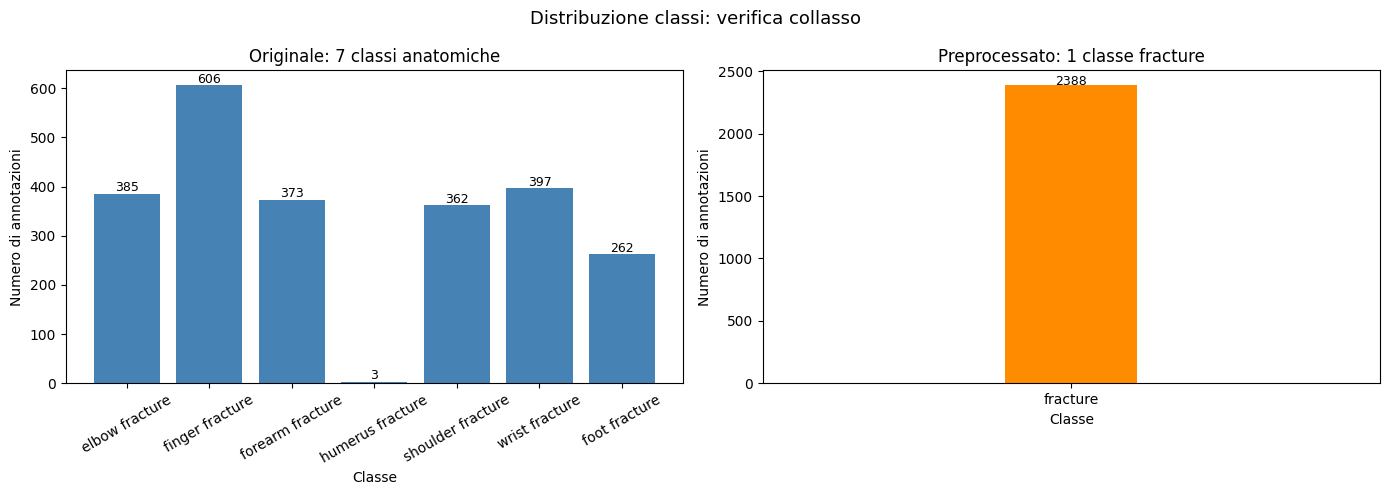

Totale annotazioni originale  : 2388
Totale annotazioni preprocessato: 2388
OK: nessuna annotazione persa.


In [15]:
def load_class_counts(dataset_dir, class_names):
    counts = {name: 0 for name in class_names}
    for label_file in dataset_dir.rglob("labels/*.txt"):
        for line in label_file.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                if cls_id < len(class_names):
                    counts[class_names[cls_id]] += 1
    return counts

ORIG_CLASSES = [
    "elbow fracture", "finger fracture", "forearm fracture",
    "humerus fracture", "shoulder fracture", "wrist fracture", "foot fracture"
]
PREP_CLASSES = ["fracture"]

counts_orig = load_class_counts(PKDARABI_ORIG, ORIG_CLASSES)
counts_prep = load_class_counts(PKDARABI_PREP, PREP_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts_orig.keys(), counts_orig.values(), color="steelblue")
axes[0].set_title("Originale: 7 classi anatomiche")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Numero di annotazioni")
axes[0].tick_params(axis="x", rotation=30)
for i, (k, v) in enumerate(counts_orig.items()):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)

axes[1].bar(counts_prep.keys(), counts_prep.values(), color="darkorange", width=0.3)
axes[1].set_xlim(-0.7, 0.7)
axes[1].set_title("Preprocessato: 1 classe fracture")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Numero di annotazioni")
for i, (k, v) in enumerate(counts_prep.items()):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=9)

total_orig = sum(counts_orig.values())
total_prep = sum(counts_prep.values())
assert total_orig == total_prep, f"Annotazioni perse: {total_orig} orig vs {total_prep} prep"

plt.suptitle("Distribuzione classi: verifica collasso", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Totale annotazioni originale  : {total_orig}")
print(f"Totale annotazioni preprocessato: {total_prep}")
print("OK: nessuna annotazione persa.")

### 4.2 Background vs fratturate per split

Abbiamo scelto questo dataset principalmente perché un dataset YOLO ben costruito deve avere una distribuzione stabile di immagini background e immagini con annotazioni in tutti e tre gli split.
Uno sbilanciamento forte o una distribuzione disomogenea tra split (come FracAtlas) introdurrebbe
bias nella valutazione delle metriche.

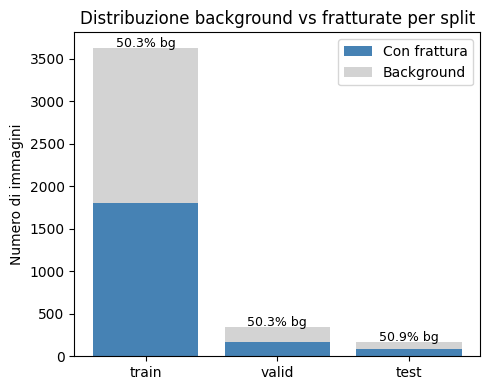

train  | totale: 3631 | annotate: 1804 | background: 1827 | box: 2088
valid  | totale:  348 | annotate:  173 | background:  175 | box:  204
test   | totale:  169 | annotate:   83 | background:   86 | box:   96


In [20]:
def split_stats(dataset_dir):
    stats = {}
    for split in ("train", "valid", "test"):
        label_dir = dataset_dir / split / "labels"
        total, background, boxes = 0, 0, 0
        for f in label_dir.glob("*.txt"):
            total += 1
            lines = [l for l in f.read_text().splitlines() if l.strip()]
            if not lines:
                background += 1
            else:
                boxes += len(lines)
        stats[split] = {
            "total": total,
            "background": background,
            "annotated": total - background,
            "boxes": boxes,
        }
    return stats

stats = split_stats(PKDARABI_PREP)

splits = list(stats.keys())
annotated = [stats[s]["annotated"] for s in splits]
background = [stats[s]["background"] for s in splits]

x = range(len(splits))
fig, ax = plt.subplots(figsize=(5, 4))
bars_ann = ax.bar(x, annotated, label="Con frattura", color="steelblue")
bars_bg  = ax.bar(x, background, bottom=annotated, label="Background", color="lightgray")

for i, s in enumerate(splits):
    total = stats[s]["total"]
    pct_bg = 100 * stats[s]["background"] / total
    ax.text(i, total + 10, f"{pct_bg:.1f}% bg", ha="center", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(splits)
ax.set_ylabel("Numero di immagini")
ax.set_title("Distribuzione background vs fratturate per split")
ax.legend()
plt.tight_layout()
plt.show()

for s in splits:
    st = stats[s]
    print(f"{s:6s} | totale: {st['total']:4d} | annotate: {st['annotated']:4d} | "
          f"background: {st['background']:4d} | box: {st['boxes']:4d}")

### 4.3 Distribuzione delle dimensioni dei bounding box

Le dimensioni delle box (già normalizzate rispetto all'immagine, range [0,1])
determinano la scala degli oggetti che il modello deve rilevare. Box molto
piccole richiedono una risoluzione di input (imgsz) elevata: se un oggetto
occupa l'1% dell'immagine a imgsz=640 risulta in pochi pixel, difficilmente
rilevabile dalla rete. Questo grafico motiva direttamente la scelta di imgsz.

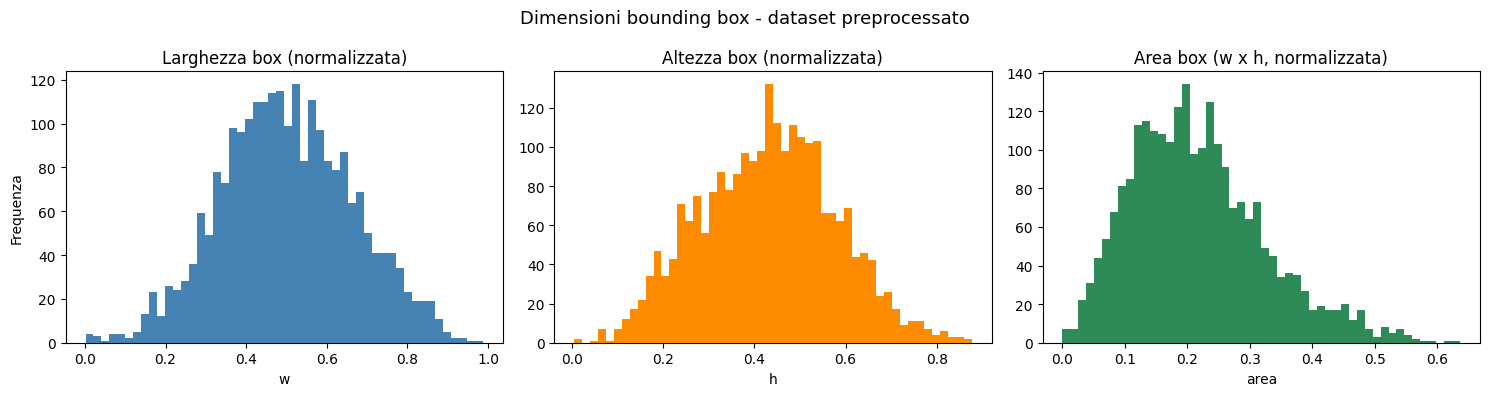

Box totali     : 2388
Area mediana   : 0.2027
Area media     : 0.2171
Area < 1%      : 6 (0.3%)
Area < 5%      : 65 (2.7%)
Area > 10%     : 2093 (87.6%)


In [21]:
def load_box_sizes(dataset_dir):
    widths, heights, areas = [], [], []
    for label_file in dataset_dir.rglob("labels/*.txt"):
        for line in label_file.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                w, h = float(parts[3]), float(parts[4])
                widths.append(w)
                heights.append(h)
                areas.append(w * h)
    return widths, heights, areas

widths, heights, areas = load_box_sizes(PKDARABI_PREP)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Larghezza box (normalizzata)")
axes[0].set_xlabel("w")
axes[0].set_ylabel("Frequenza")

axes[1].hist(heights, bins=50, color="darkorange", edgecolor="none")
axes[1].set_title("Altezza box (normalizzata)")
axes[1].set_xlabel("h")

axes[2].hist(areas, bins=50, color="seagreen", edgecolor="none")
axes[2].set_title("Area box (w x h, normalizzata)")
axes[2].set_xlabel("area")

plt.suptitle("Dimensioni bounding box - dataset preprocessato", fontsize=13)
plt.tight_layout()
plt.show()

areas_arr = np.array(areas)
print(f"Box totali     : {len(areas_arr)}")
print(f"Area mediana   : {np.median(areas_arr):.4f}")
print(f"Area media     : {np.mean(areas_arr):.4f}")
print(f"Area < 1%      : {(areas_arr < 0.01).sum()} ({100*(areas_arr < 0.01).mean():.1f}%)")
print(f"Area < 5%      : {(areas_arr < 0.05).sum()} ({100*(areas_arr < 0.05).mean():.1f}%)")
print(f"Area > 10%     : {(areas_arr > 0.10).sum()} ({100*(areas_arr > 0.10).mean():.1f}%)")

Rispetto a FracAtlas, le bounding box sono molto più grandi in questo dataset. Sono circa 20% dell'immagine (guardando l'area media) e quasi la totalità delle immagini supera almeno il 10%. 

con **imgsz=640** otteremmo una bounding box in media di 128x128px effettivi, sufficiente per riconoscere la frattura.


### 4.4 Immagini con annotazioni

Visualizziamo un campione di immagini con le bounding box disegnate per
verificare la qualita' delle annotazioni e avere un riferimento visivo
di cosa il modello deve rilevare.

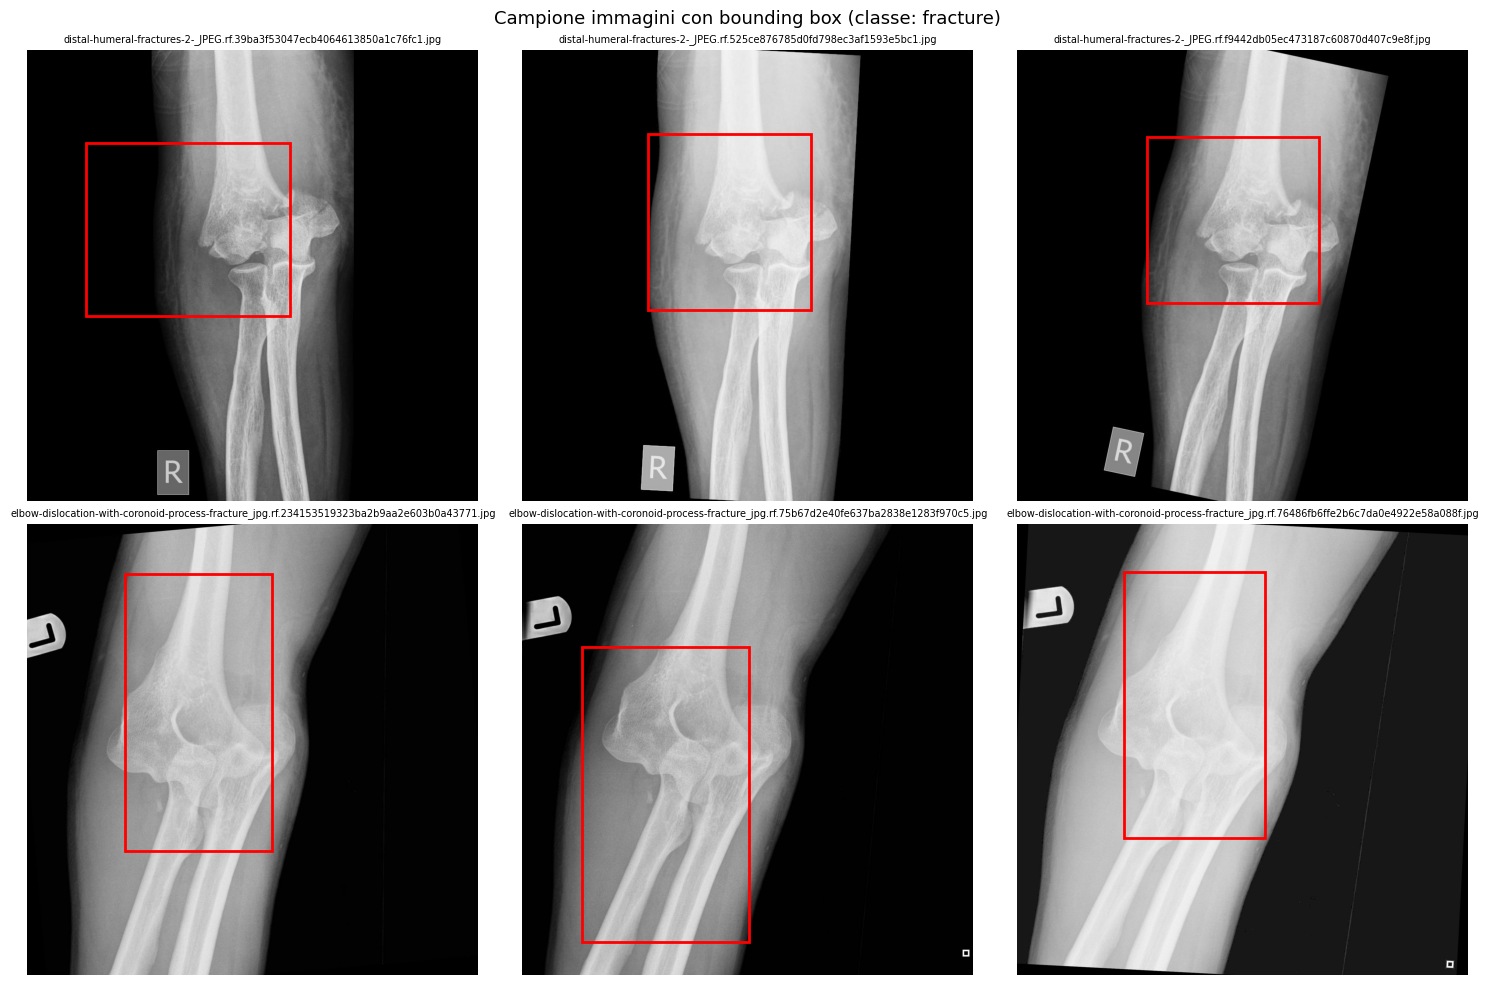

In [5]:
def draw_boxes(img_path, label_path, class_names):
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    fig, ax = plt.subplots(1, figsize=(5, 5))
    ax.imshow(img, cmap="gray")

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, class_names[cls_id], color="red", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"))

    ax.axis("off")
    ax.set_title(img_path.name, fontsize=8)
    return fig


train_img_dir   = PKDARABI_PREP / "train" / "images"
train_label_dir = PKDARABI_PREP / "train" / "labels"

# Seleziona le prime 6 immagini che hanno almeno una box
samples = []
for img_path in sorted(train_img_dir.iterdir()):
    label_path = train_label_dir / (img_path.stem + ".txt")
    if label_path.exists():
        lines = [l for l in label_path.read_text().splitlines() if l.strip()]
        if lines:
            samples.append((img_path, label_path))
    if len(samples) == 6:
        break

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (img_path, label_path) in zip(axes.flat, samples):
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    ax.imshow(img, cmap="gray")
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        rect = patches.Rectangle(
            (x1, y1), bw * w, bh * h,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
    ax.set_title(img_path.name, fontsize=7)
    ax.axis("off")

plt.suptitle("Campione immagini con bounding box (classe: fracture)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Training Baseline - YOLOv11 Nano

Il primo modello addestrato e' la baseline: YOLOv11 Nano con configurazione
conservativa, progettata per ottenere un training stabile e riproducibile
sull'hardware utilizzato.

### Parametri di training

*Modello*: ***yolo11n.pt***
Nano e' il modello piu' leggero della famiglia YOLOv11 (~2.6M parametri).
Viene inizializzato con pesi pre-allenati su COCO (transfer learning),
che forniscono feature generali di basso livello (bordi, texture, forme)
gia' utili per le radiografie, riducendo il numero di epoche necessarie
alla convergenza.

***imgsz=640***
Come motivato dall'EDA, le box hanno area mediana del 20% dell'immagine.
A 640px una box tipica occupa ~128x128 pixel, sufficiente per il Nano.
Valori piu' alti aumenterebbero il consumo di VRAM senza beneficio misurabile
su questo dataset.

***batch=16***
Valore di riferimento sicuro per il Nano a imgsz=640 (~1.5GB VRAM con AMP).
Batch piu' grandi (es. 32) hanno causato overflow fp16 e collasso del training
nei tentativi precedenti su hardware identico. La BatchNorm e' stabile con 16
campioni per step anche in presenza di ~50% di immagini background.

***epochs=100***
Le curve di detection su dataset di questa dimensione richiedono almeno
100 epoche per convergere. Valori inferiori (50 epoche nei tentativi precedenti)
fermavano il training durante fasi di oscillazione normale, prima del plateau
vero.

***patience=25***
La mAP sul validation set oscilla fisiologicamente di +/-0.01-0.02 tra epoche
consecutive. Una patience troppo bassa (es. 10) attiva l'early stopping durante
queste oscillazioni normali. Con patience=25 il modello attraversa almeno
2-3 cicli di oscillazione prima che il training si interrompa.

***optimizer=auto***
Lascia a Ultralytics la scelta dell'ottimizzatore in base al modello.
Per YOLOv11 seleziona SGD con momentum=0.937 e weight_decay=0.0005,
configurazione ottimizzata dagli autori su migliaia di esperimenti.

***lr0=0.01, lrf=0.01***
Learning rate iniziale standard per fine-tuning da pesi COCO. Il decay
al termine del training e' gestito dallo scheduler cosine di Ultralytics.

***mosaic=1.0***
Il mosaic combina 4 immagini in una durante il training, aumentando
artificialmente la varianza dei campioni e la frequenza con cui il modello
vede fratture per step. Con il 50% di background per split, il mosaic
garantisce che ogni batch contenga esempi positivi. Non viene disabilitato:
nei tentativi precedenti `mosaic=0.0` ha peggiorato la mAP da 0.265 a 0.213.

***cls=0.5***
Peso della classification loss. Valore default Ultralytics, ottimizzato
su COCO. Con una sola classe il contributo della cls_loss e' gia' minimo:
alzarlo (es. a 1.0 come in un tentativo precedente) ha dimezzato la mAP
destabilizzando il bilanciamento delle perdite.

***amp=True***
Automatic Mixed Precision: usa fp16 dove possibile per ridurre il consumo
di VRAM e accelerare il training. Con batch=16 e imgsz=640 il rischio di
overflow fp16 e' basso. Se compaiono NaN nelle prime epoche e' il primo
parametro da disabilitare per diagnosticare il problema.


In [6]:
BASELINE_CFG = {
    "model"    : "yolo11n.pt",
    "data"     : str((PKDARABI_PREP / "data.yaml").resolve()),
    "imgsz"    : 640,
    "batch"    : 16,
    "epochs"   : 100,
    "patience" : 25,
    "optimizer": "auto",
    "lr0"      : 0.01,
    "lrf"      : 0.01,
    "mosaic"   : 1.0,
    "cls"      : 0.5,
    "amp"      : True,
    "project"  : str((BASE_DIR / "runs").resolve()),
    "name"     : "baseline_nano",
    "exist_ok" : False,
}

for k, v in BASELINE_CFG.items():
    print(f"  {k:<12}: {v}")

  model       : yolo11n.pt
  data        : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\data.yaml
  imgsz       : 640
  batch       : 16
  epochs      : 100
  patience    : 25
  optimizer   : auto
  lr0         : 0.01
  lrf         : 0.01
  mosaic      : 1.0
  cls         : 0.5
  amp         : True
  project     : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs
  name        : baseline_nano
  exist_ok    : False


In [7]:
model = YOLO(BASELINE_CFG["model"])
results = model.train(**BASELINE_CFG)

New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_r

Questa cella serve a riprendere un allenamento tramite last.pt (che Ultralytics rende disponibile) nel caso sia stoppato per qualsiasi motivo.


In [ ]:
BASELINE_LAST = BASE_DIR / "runs" / "baseline_nano" / "weights" / "last.pt"

assert BASELINE_LAST.exists(), f"Checkpoint non trovato: {BASELINE_LAST}"

model_resume = YOLO(str(BASELINE_LAST))
results_resume = model_resume.train(resume=True)

Ora carichiamo i pesi migliori (*best.pt*) e valutiamo il modello su validation
e test set separatamente.

In [9]:
model_baseline = YOLO(str(BASELINE_BEST))

metrics_val = model_baseline.val(
    data=str((PKDARABI_PREP / "data.yaml").resolve()),
    split="val",
    imgsz=640,
    batch=16,
    project=str((BASE_DIR / "runs").resolve()),
    name="baseline_nano_eval_val",
    exist_ok=True,
    verbose=False,
)

metrics_test = model_baseline.val(
    data=str((PKDARABI_PREP / "data.yaml").resolve()),
    split="test",
    imgsz=640,
    batch=16,
    project=str((BASE_DIR / "runs").resolve()),
    name="baseline_nano_eval_test",
    exist_ok=True,
    verbose=False,
)

def print_metrics(label, m):
    p  = m.box.mp
    r  = m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    print(f"\n=== {label} ===")
    print(f"  mAP50    : {m.box.map50:.4f}")
    print(f"  mAP50-95 : {m.box.map:.4f}")
    print(f"  Precision: {p:.4f}")
    print(f"  Recall   : {r:.4f}")
    print(f"  F1       : {f1:.4f}")

print_metrics("Baseline Nano - Validation", metrics_val)
print_metrics("Baseline Nano - Test", metrics_test)

Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 10.42.9 MB/s, size: 8.9 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\valid\labels.cache... 348 images, 175 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 6.2it/s 3.6s0.1s
                   all        348        204      0.405      0.298      0.292        0.1
Speed: 1.8ms preprocess, 4.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\baseline_nano_eval_val
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop


| Metrica    | Validation | Test   |
|------------|------------|--------|
| mAP50      | 0.2920     | 0.2131 |
| mAP50-95   | 0.1000     | 0.0543 |
| Precision  | 0.4055     | 0.2621 |
| Recall     | 0.2975     | 0.2917 |
| F1         | 0.3432     | 0.2761 |

Il modello converge in modo stabile: nessun collasso numerico, early stopping
a epoca 83 su 100. Il gap val/test su mAP50 e' 0.079, un valore che indica
overfitting moderato. Il recall e' sostanzialmente allineato tra i due split
(0.298 vs 0.292), il che suggerisce che la capacita' del modello di trovare
le fratture e' consistente. Il calo principale sul test riguarda la precision
(0.406 vs 0.262): il modello genera piu' falsi positivi su immagini che non
ha mai visto durante la selezione del best checkpoint.

Questo e' il comportamento atteso per una baseline non ottimizzata. Il modello
sa trovare le fratture (recall stabile) ma non e' ancora abbastanza selettivo
(precision bassa sul test). L'ottimizzazione si concentrera' su questo gap.

## 7. K-Fold Cross-Validation

Le metriche ottenute con lo split fisso (train 3631, valid 348, test 169) sono basse e potenzialmente instabili. Il problema e' strutturale: con solo 169 immagini di test (4% del totale) e 348 di validation (8.4%), una manciata di immagini difficili sposta sensibilmente le metriche, e il *best checkpoint* viene selezionato su un val set molto piccolo, con rischio di overfit alla particolare composizione di quello split.

La tecnica standard per dataset di piccole dimensioni (<5K immagini) in medical imaging e' la **K-Fold Cross-Validation stratificata**:

1. Si uniscono tutte le immagini in un unico pool (4148 immagini)
2. Si stratifica per presenza di frattura (binario: 1 se l'immagine ha almeno una box, 0 se e' background), in modo che ogni fold contenga la stessa proporzione di fratturate/sane
3. Si dividono in K=5 fold da circa 830 immagini ciascuno
4. Per ogni fold k: si allena un modello su K-1 fold (circa 3318 immagini) e si valuta sul fold rimanente (circa 830 immagini)
5. Si riportano **media +/- deviazione standard** delle metriche sui 5 fold

Vantaggi rispetto allo split fisso:

- Ogni immagine viene usata esattamente una volta come validation
- Il validation set effettivo passa da 348 a circa 830 immagini -> metriche piu' stabili
- Si neutralizza la *lotteria dello split*: l'attuale test set da 169 immagini potrebbe semplicemente essere piu' difficile della media
- La media +/- std fornisce una stima onesta della performance reale del modello

Per il confronto pulito con la baseline, si usano gli **stessi iperparametri** di BASELINE_CFG (yolo11n, imgsz=640, batch=16, epochs=100, patience=25, ecc.). L'unica variabile cambiata e' lo split dei dati.

In [2]:
from sklearn.model_selection import StratifiedKFold

PKDARABI_KFOLD = DATASETS_DIR / "preprocessed" / "pkdarabi_kfold"
N_FOLDS = 5
KFOLD_SEED = 42

# raccolta di tutte le immagini con etichetta binaria has_fracture
all_imgs = []
all_labels = []

for split in ("train", "valid", "test"):
    img_dir = PKDARABI_PREP / split / "images"
    lbl_dir = PKDARABI_PREP / split / "labels"
    for img in sorted(img_dir.iterdir()):
        if img.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
            continue
        lbl = lbl_dir / (img.stem + ".txt")
        has_fx = lbl.exists() and any(l.strip() for l in lbl.read_text().splitlines())
        all_imgs.append((img, lbl if lbl.exists() else None))
        all_labels.append(int(has_fx))

n_total = len(all_imgs)
n_fx = sum(all_labels)
n_bg = n_total - n_fx
print(f"Pool totale: {n_total} immagini")
print(f"  fratturate: {n_fx} ({100*n_fx/n_total:.1f}%)")
print(f"  background: {n_bg} ({100*n_bg/n_total:.1f}%)")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=KFOLD_SEED)
folds = list(skf.split(all_imgs, all_labels))

print(f"\nDistribuzione per fold (stratificata su has_fracture):")
for k, (train_idx, val_idx) in enumerate(folds):
    val_labels = [all_labels[i] for i in val_idx]
    train_labels = [all_labels[i] for i in train_idx]
    print(f"  fold {k}: train={len(train_idx)} (fx={sum(train_labels)}, bg={len(train_labels)-sum(train_labels)}), "
          f"val={len(val_idx)} (fx={sum(val_labels)}, bg={len(val_labels)-sum(val_labels)})")

Pool totale: 4148 immagini
  fratturate: 2060 (49.7%)
  background: 2088 (50.3%)

Distribuzione per fold (stratificata su has_fracture):
  fold 0: train=3318 (fx=1648, bg=1670), val=830 (fx=412, bg=418)
  fold 1: train=3318 (fx=1648, bg=1670), val=830 (fx=412, bg=418)
  fold 2: train=3318 (fx=1648, bg=1670), val=830 (fx=412, bg=418)
  fold 3: train=3319 (fx=1648, bg=1671), val=829 (fx=412, bg=417)
  fold 4: train=3319 (fx=1648, bg=1671), val=829 (fx=412, bg=417)


In [ ]:
def materialize_fold(fold_idx, train_idx, val_idx):
    fold_dir = PKDARABI_KFOLD / f"fold_{fold_idx}"
    train_img_dir = fold_dir / "train" / "images"
    val_img_dir = fold_dir / "val" / "images"

    # idempotenza: se gia' completo, skip
    if train_img_dir.exists() and val_img_dir.exists():
        actual_train = sum(1 for _ in train_img_dir.iterdir())
        actual_val = sum(1 for _ in val_img_dir.iterdir())
        if actual_train == len(train_idx) and actual_val == len(val_idx):
            print(f"  fold {fold_idx}: gia' presente (train={actual_train}, val={actual_val}), skip")
            return fold_dir

    for split in ("train", "val"):
        (fold_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (fold_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    for split_name, indices in [("train", train_idx), ("val", val_idx)]:
        for i in indices:
            img_path, lbl_path = all_imgs[i]
            dst_img = fold_dir / split_name / "images" / img_path.name
            if not dst_img.exists():
                shutil.copy2(img_path, dst_img)
            dst_lbl = fold_dir / split_name / "labels" / (img_path.stem + ".txt")
            if not dst_lbl.exists():
                if lbl_path is not None:
                    shutil.copy2(lbl_path, dst_lbl)
                else:
                    dst_lbl.write_text("")

    yaml_content = {
        "path": str(fold_dir.resolve()),
        "train": "train/images",
        "val": "val/images",
        "nc": 1,
        "names": ["fracture"],
    }
    with open(fold_dir / "data.yaml", "w") as f:
        yaml.dump(yaml_content, f, default_flow_style=False, allow_unicode=True)

    print(f"  fold {fold_idx}: creato (train={len(train_idx)}, val={len(val_idx)})")
    return fold_dir


PKDARABI_KFOLD.mkdir(parents=True, exist_ok=True)
print(f"Creazione fold in: {PKDARABI_KFOLD.resolve()}\n")
for k, (tr, vl) in enumerate(folds):
    materialize_fold(k, tr, vl)

print("\nFatto.")

### 7.1 Training sui 5 fold

Si lancia un training per ogni fold con gli stessi iperparametri della baseline (BASELINE_CFG). L'unica differenza e' il **data.yaml**, che punta allo split del fold corrente. Tempo totale stimato: circa 5 ore.

La cella e' idempotente: se per un fold esiste gia' *best.pt*, il training viene saltato. Questo permette di rilanciare la cella senza ripartire da zero.

In [3]:
KFOLD_CFG_BASE = {
    "model"    : "yolo11n.pt",
    "imgsz"    : 640,
    "batch"    : 16,
    "epochs"   : 100,
    "patience" : 25,
    "optimizer": "auto",
    "lr0"      : 0.01,
    "lrf"      : 0.01,
    "mosaic"   : 1.0,
    "cls"      : 0.5,
    "amp"      : True,
    "project"  : str((BASE_DIR / "runs").resolve()),
    "exist_ok" : False,
}

for k in range(N_FOLDS):
    fold_data_yaml = PKDARABI_KFOLD / f"fold_{k}" / "data.yaml"
    run_name = f"kfold_nano_fold{k}"
    run_dir = BASE_DIR / "runs" / run_name
    best_pt = run_dir / "weights" / "best.pt"

    if best_pt.exists():
        print(f"=== fold {k}: best.pt gia' presente in {run_dir}, skip ===\n")
        continue

    print(f"\n=== Training fold {k}/{N_FOLDS-1} ===")
    cfg = {
        **KFOLD_CFG_BASE,
        "data": str(fold_data_yaml.resolve()),
        "name": run_name,
    }
    model = YOLO(cfg["model"])
    model.train(**cfg)

=== fold 0: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold0, skip ===

=== fold 1: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold1, skip ===

=== fold 2: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold2, skip ===

=== fold 3: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold3, skip ===


=== Training fold 4/4 ===
New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\

Se uno dei training viene interrotto, si imposta RESUME_FOLD al fold da riprendere e si lancia la cella seguente. Ultralytics riprende da *last.pt* automaticamente.

In [ ]:
RESUME_FOLD = 4  # cambiare con il fold da riprendere

LAST_PT = BASE_DIR / "runs" / f"kfold_nano_fold{RESUME_FOLD}" / "weights" / "last.pt"
assert LAST_PT.exists(), f"Checkpoint non trovato: {LAST_PT}"

model_resume = YOLO(str(LAST_PT))
results_resume = model_resume.train(resume=True)

### 7.2 Valutazione e aggregazione

Per ogni fold si caricano i pesi *best.pt* e si valuta sul val del fold (cioe' sulle immagini che quel modello non ha mai visto). Si calcolano poi media e deviazione standard delle metriche sui 5 fold: questa e' la stima onesta della performance del modello su questo dataset.

In [4]:
fold_metrics = []

for k in range(N_FOLDS):
    fold_data_yaml = PKDARABI_KFOLD / f"fold_{k}" / "data.yaml"
    best_pt = BASE_DIR / "runs" / f"kfold_nano_fold{k}" / "weights" / "best.pt"

    assert best_pt.exists(), f"best.pt non trovato per fold {k}: {best_pt}"

    model_k = YOLO(str(best_pt))
    m = model_k.val(
        data=str(fold_data_yaml.resolve()),
        split="val",
        imgsz=640,
        batch=16,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"kfold_nano_fold{k}_eval",
        exist_ok=True,
        verbose=False,
    )
    p, r = m.box.mp, m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    fold_metrics.append({
        "fold": k,
        "mAP50": m.box.map50,
        "mAP50-95": m.box.map,
        "Precision": p,
        "Recall": r,
        "F1": f1,
    })

df_fold = pd.DataFrame(fold_metrics)
print("=== Metriche per fold ===")
print(df_fold.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== Aggregato (media +/- std sui 5 fold) ===")
for col in ("mAP50", "mAP50-95", "Precision", "Recall", "F1"):
    mu, sd = df_fold[col].mean(), df_fold[col].std()
    print(f"  {col:<10}: {mu:.4f} +/- {sd:.4f}")

Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 6.71.0 MB/s, size: 11.0 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_kfold\fold_0\val\labels.cache... 830 images, 418 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.8it/s 10.8s0.2s
                   all        830        474      0.708      0.555      0.645      0.317
Speed: 2.9ms preprocess, 4.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\kfold_nano_fold0_eval
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 

### 7.3 Risultati K-Fold e confronto con baseline

#### Metriche per fold (best epoch su val del fold)

| Fold | mAP50  | mAP50-95 | Precision | Recall | F1     |
|------|--------|----------|-----------|--------|--------|
| 0    | 0.6461 | 0.3161   | 0.7051    | 0.5570 | 0.6223 |
| 1    | 0.6600 | 0.3248   | 0.7066    | 0.5946 | 0.6458 |
| 2    | 0.6801 | 0.3524   | 0.7894    | 0.5954 | 0.6788 |
| 3    | 0.6115 | 0.3005   | 0.7151    | 0.5189 | 0.6014 |
| 4    | 0.6526 | 0.3448   | 0.7379    | 0.5619 | 0.6380 |

#### Aggregato sui 5 fold

| Metrica    | Media  | Std    |
|------------|--------|--------|
| mAP50      | 0.6501 | 0.0250 |
| mAP50-95   | 0.3277 | 0.0211 |
| Precision  | 0.7308 | 0.0353 |
| Recall     | 0.5655 | 0.0316 |
| F1         | 0.6373 | 0.0288 |

#### Confronto diretto con la baseline a split fisso

| Metrica    | Baseline Val | Baseline Test | K-Fold (media +/- std) | Guadagno vs Test |
|------------|--------------|---------------|------------------------|------------------|
| mAP50      | 0.2920       | 0.2131        | **0.6501 +/- 0.0250**  | +0.4370 (+205%)  |
| mAP50-95   | 0.1000       | 0.0543        | **0.3277 +/- 0.0211**  | +0.2734 (+503%)  |
| Precision  | 0.4055       | 0.2621        | **0.7308 +/- 0.0353**  | +0.4687 (+179%)  |
| Recall     | 0.2975       | 0.2917        | **0.5655 +/- 0.0316**  | +0.2738 (+94%)   |
| F1         | 0.3432       | 0.2761        | **0.6373 +/- 0.0288**  | +0.3612 (+131%)  |

#### Lettura dei risultati

Il salto di performance e' molto significativo: mAP50 passa da 0.213 a 0.650 (triplicato), F1 da 0.276 a 0.637. Questo conferma in modo netto due cose:

1. **L'architettura e gli iperparametri erano gia' adeguati**. Non era il modello a essere debole: era la valutazione a essere instabile. Il test set della baseline (169 immagini) e' troppo piccolo e si era rivelato evidentemente "sfortunato", contenendo immagini sistematicamente piu' difficili della media.

2. **La K-Fold CV elimina la lotteria dello split**. Con ~830 immagini di val per fold (vs 348/169 della baseline) le metriche diventano stabili: la deviazione standard mAP50 e' solo 0.025 (4% del valore), e tutti e 5 i fold cadono nel range [0.61, 0.68]. Nessun fold "drammatico" come il test originale.

La stima onesta delle performance del modello yolo11n su questo dataset e' dunque **mAP50 = 0.65 +/- 0.025**, non 0.21. Le metriche di test della baseline erano fuorvianti.

Da questo punto in poi, il K-Fold diventa il *protocollo standard* di valutazione del progetto: ogni nuovo esperimento (es. CLAHE migliorato, modelli piu' grandi, hyperparameter tuning) verra' confrontato con questa baseline K-Fold, non con lo split fisso.

## 8. Augmentation: Preprocessing CLAHE

CLAHE (Contrast Limited Adaptive Histogram Equalization) e' una tecnica di
miglioramento del contrasto locale sviluppata specificamente per imaging medico.
CLAHE divide l'immagine in tile e applica la equalizzazione indipendentemente in ciascuna,
limitando l'amplificazione del rumore tramite un parametro `*lipLimit*.

Su radiografie e' utile perche' le fratture sono spesso zone di contrasto
molto basso: linee sottili o discontinuita' quasi impercettibili tra tessuto
osseo integro e fratturato. Aumentare il contrasto locale rende queste
strutture piu' distinguibili.

CLAHE viene applicato offline (prima del training) e non on-the-fly durante
il training. Questo garantisce che train, validation e test ricevano esattamente
la stessa trasformazione con gli stessi parametri, eliminando una fonte di
varianza tra split che nei tentativi precedenti aveva contribuito a un gap
val/test elevato. Le immagini trasformate vengono salvate in una cartella
separata (preprocessed/pkdarabi_clahe) lasciando intatto il dataset originale
preprocessato.

### Parametri scelti

- *clipLimit=2.0*: valore standard per imaging medico. Limita l'amplificazione
  del rumore nelle zone omogenee (es. tessuti molli) evitando artefatti.
- *tileGridSize=(8,8)*: dimensione delle tile. Con immagini X-ray tipicamente
  tra 512 e 1024px, tile da 8x8 producono una equalizzazione locale sufficientemente
  granulare senza introdurre discontinuita' visibili ai bordi.




In [11]:
def apply_clahe_to_dataset(src_dir, dst_dir, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    processed = 0
    skipped = 0

    for split in ("train", "valid", "test"):
        src_img_dir = src_dir / split / "images"
        dst_img_dir = dst_dir / split / "images"
        dst_img_dir.mkdir(parents=True, exist_ok=True)

        for img_path in sorted(src_img_dir.iterdir()):
            if img_path.suffix.lower() not in img_extensions:
                continue
            dst_path = dst_img_dir / img_path.name
            if dst_path.exists():
                skipped += 1
                continue

            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  WARN: impossibile leggere {img_path.name}, saltata")
                continue

            img_clahe = clahe.apply(img)
            img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)
            cv2.imwrite(str(dst_path), img_rgb)
            processed += 1

        print(f"  [{split}] processate: {processed}, skippate: {skipped}")
        processed = 0
        skipped = 0

    # Copia label invariate (le annotazioni non cambiano)
    for split in ("train", "valid", "test"):
        src_lbl = src_dir / split / "labels"
        dst_lbl = dst_dir / split / "labels"
        if dst_lbl.exists():
            print(f"  [{split}] labels gia' presenti, skip")
            continue
        shutil.copytree(src_lbl, dst_lbl)
        print(f"  [{split}] labels copiate")

    # Copia data.yaml e aggiorna path
    yaml_dst = dst_dir / "data.yaml"
    yaml_content = {
        "path" : str(dst_dir.resolve()),
        "train": "train/images",
        "val"  : "valid/images",
        "test" : "test/images",
        "nc"   : 1,
        "names": ["fracture"],
    }
    with open(yaml_dst, "w") as f:
        yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)
    print(f"\ndata.yaml scritto in: {yaml_dst}")


print("Applico CLAHE...")
apply_clahe_to_dataset(PKDARABI_PREP, PKDARABI_CLAHE)
print("\nDone.")

Applico CLAHE...
  [train] processate: 3631, skippate: 0
  [valid] processate: 348, skippate: 0
  [test] processate: 169, skippate: 0
  [train] labels copiate
  [valid] labels copiate
  [test] labels copiate

data.yaml scritto in: Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe\data.yaml

Done.


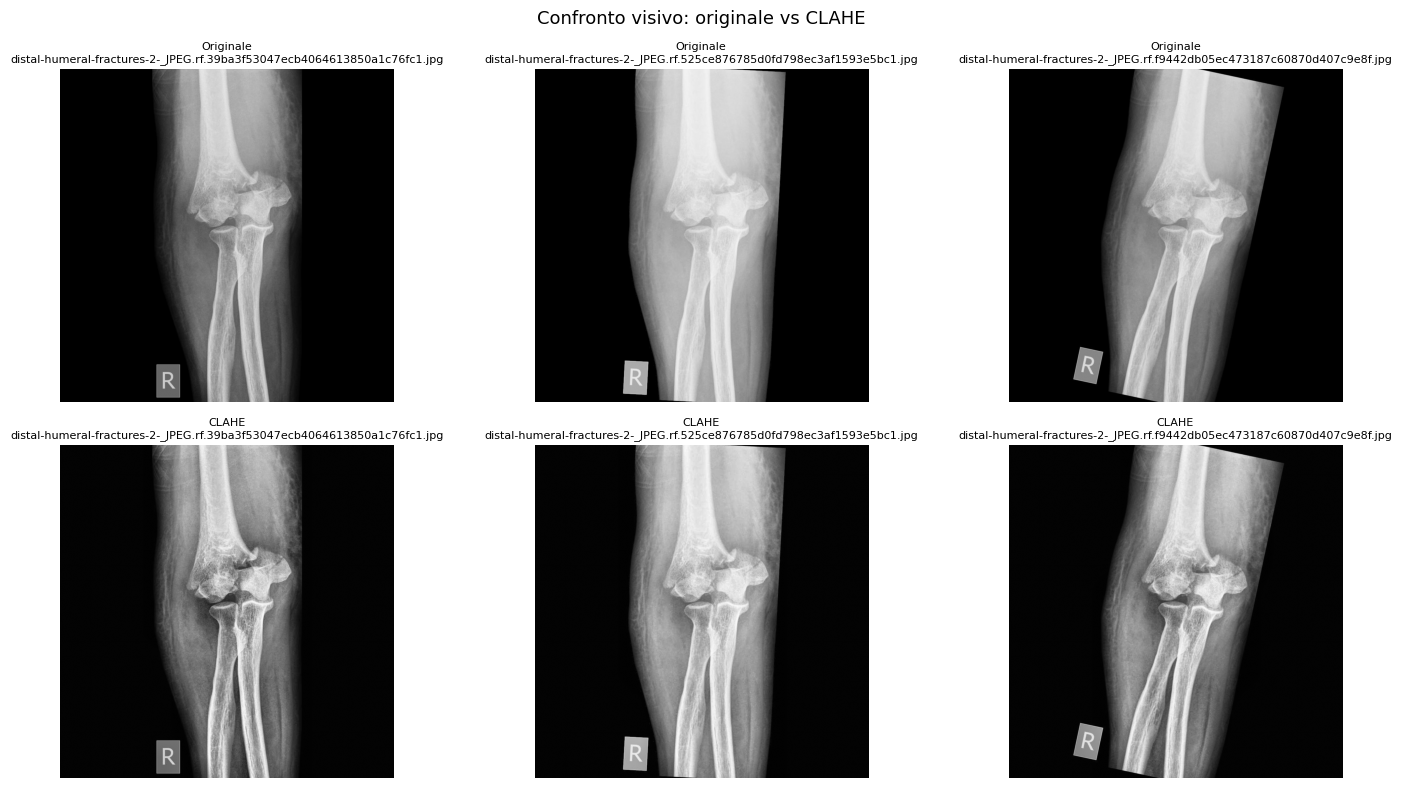

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

train_img_orig  = PKDARABI_PREP  / "train" / "images"
train_img_clahe = PKDARABI_CLAHE / "train" / "images"
train_lbl       = PKDARABI_PREP  / "train" / "labels"

samples = []
for img_path in sorted(train_img_orig.iterdir()):
    lbl = train_lbl / (img_path.stem + ".txt")
    if lbl.exists() and any(l.strip() for l in lbl.read_text().splitlines()):
        samples.append(img_path)
    if len(samples) == 3:
        break

for col, img_path in enumerate(samples):
    img_orig  = np.array(Image.open(img_path).convert("L"))
    img_clahe = np.array(Image.open(train_img_clahe / img_path.name).convert("L"))

    axes[0][col].imshow(img_orig,  cmap="gray", vmin=0, vmax=255)
    axes[0][col].set_title(f"Originale\n{img_path.name}", fontsize=8)
    axes[0][col].axis("off")

    axes[1][col].imshow(img_clahe, cmap="gray", vmin=0, vmax=255)
    axes[1][col].set_title(f"CLAHE\n{img_path.name}", fontsize=8)
    axes[1][col].axis("off")

axes[0][0].set_ylabel("Originale", fontsize=10)
axes[1][0].set_ylabel("CLAHE", fontsize=10)

plt.suptitle("Confronto visivo: originale vs CLAHE", fontsize=13)
plt.tight_layout()
plt.show()

E' evidente l'aumento di contrasto che CLAHE ha prodotto alle immagini. vediamo se questa augmentation migliora il modello baseline.

In [2]:
CLAHE_CFG = {
    "model"    : "yolo11n.pt",
    "data"     : str((PKDARABI_CLAHE / "data.yaml").resolve()),
    "imgsz"    : 640,
    "batch"    : 16,
    "epochs"   : 100,
    "patience" : 25,
    "optimizer": "auto",
    "lr0"      : 0.01,
    "lrf"      : 0.01,
    "mosaic"   : 1.0,
    "cls"      : 0.5,
    "amp"      : True,
    "project"  : str((BASE_DIR / "runs").resolve()),
    "name"     : "nano_clahe",
    "exist_ok" : False,
}

for k, v in CLAHE_CFG.items():
    print(f"  {k:<12}: {v}")

  model       : yolo11n.pt
  data        : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe\data.yaml
  imgsz       : 640
  batch       : 16
  epochs      : 100
  patience    : 25
  optimizer   : auto
  lr0         : 0.01
  lrf         : 0.01
  mosaic      : 1.0
  cls         : 0.5
  amp         : True
  project     : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs
  name        : nano_clahe
  exist_ok    : False


In [3]:
model_clahe = YOLO(CLAHE_CFG["model"])
results_clahe = model_clahe.train(**CLAHE_CFG)

New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, 

In [ ]:
CLAHE_LAST = BASE_DIR / "runs" / "nano_clahe" / "weights" / "last.pt"

assert CLAHE_LAST.exists(), f"Checkpoint non trovato: {CLAHE_LAST}"

model_clahe_resume = YOLO(str(CLAHE_LAST))
results_clahe_resume = model_clahe_resume.train(resume=True)

Adesso guardiamo le metriche di YOLO nano con CLAHE e lo confrontiamo al modello baseline.

In [6]:
CLAHE_BEST = BASE_DIR / "runs" / "nano_clahe" / "weights" / "best.pt"
CLAHE_RESULTS_CSV = BASE_DIR / "runs" / "nano_clahe" / "results.csv"

assert CLAHE_BEST.exists(), f"best.pt non trovato: {CLAHE_BEST}"

df_clahe = pd.read_csv(CLAHE_RESULTS_CSV)
df_clahe.columns = df_clahe.columns.str.strip()

best_idx = df_clahe["metrics/mAP50(B)"].idxmax()
best_row = df_clahe.loc[best_idx]

p_val  = best_row["metrics/precision(B)"]
r_val  = best_row["metrics/recall(B)"]
f1_val = 2 * p_val * r_val / (p_val + r_val + 1e-9)

print("=== Nano + CLAHE - Validation (best epoch) ===")
print(f"  Epoch      : {int(best_row['epoch'])}/{int(df_clahe['epoch'].max())}")
print(f"  mAP50      : {best_row['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95   : {best_row['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision  : {p_val:.4f}")
print(f"  Recall     : {r_val:.4f}")
print(f"  F1         : {f1_val:.4f}")

model_clahe_eval = YOLO(str(CLAHE_BEST))

metrics_clahe_val = model_clahe_eval.val(
    data=str((PKDARABI_CLAHE / "data.yaml").resolve()),
    split="val",
    imgsz=640,
    batch=16,
    project=str((BASE_DIR / "runs").resolve()),
    name="nano_clahe_eval_val",
    exist_ok=True,
    verbose=False,
)

metrics_clahe_test = model_clahe_eval.val(
    data=str((PKDARABI_CLAHE / "data.yaml").resolve()),
    split="test",
    imgsz=640,
    batch=16,
    project=str((BASE_DIR / "runs").resolve()),
    name="nano_clahe_eval_test",
    exist_ok=True,
    verbose=False,
)

def print_metrics(label, m):
    p  = m.box.mp
    r  = m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    print(f"\n=== {label} ===")
    print(f"  mAP50    : {m.box.map50:.4f}")
    print(f"  mAP50-95 : {m.box.map:.4f}")
    print(f"  Precision: {p:.4f}")
    print(f"  Recall   : {r:.4f}")
    print(f"  F1       : {f1:.4f}")

print_metrics("Nano + CLAHE - Validation", metrics_clahe_val)
print_metrics("Nano + CLAHE - Test", metrics_clahe_test)

=== Nano + CLAHE - Validation (best epoch) ===
  Epoch      : 42/67
  mAP50      : 0.2790
  mAP50-95   : 0.1024
  Precision  : 0.4467
  Recall     : 0.2892
  F1         : 0.3511
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 173.022.9 MB/s, size: 26.2 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe\valid\labels.cache... 348 images, 175 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 7.9it/s 2.8s<0.2s
                   all        348        204      0.468      0.279      0.278      0.103
Speed: 1.2ms preprocess, 2.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to C:\Users\e

### Confronto Baseline vs Nano + CLAHE

| Metrica        | Baseline - Val | Baseline - Test | Nano CLAHE - Val | Nano CLAHE - Test |
|----------------|----------------|-----------------|------------------|-------------------|
| mAP50          | **0.2920**     | **0.2131**      | 0.2782           | 0.2061            |
| mAP50-95       | 0.1000         | 0.0543          | **0.1025**       | **0.0566**        |
| Precision      | 0.4055         | 0.2621          | 0.4682           | **0.5493**        |
| Recall         | **0.2975**     | **0.2917**      | 0.2794           | 0.1667            |
| F1             | 0.3432         | **0.2761**      | **0.3500**       | 0.2557            |

CLAHE non ha migliorato le performance del modello. La metrica principale,
mAP50, e' peggiore su entrambi i split: sul validation scende da 0.292 a
0.278, sul test da 0.213 a 0.206.

Il dato piu' critico e' il recall sul test: scende da 0.292 a 0.167. Questo
significa che il modello con CLAHE manca quasi il doppio delle fratture reali
rispetto alla baseline. In un contesto clinico questo e' il tipo di errore
piu' grave: una frattura non rilevata e' piu' pericolosa di un falso allarme.